### implementacja modelu

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class Module:
    def __call__(self, *args, **kwds):
        return self.forward(*args, **kwds)
    def forward(self, *args, **kwds):
        raise NotImplementedError
    def backward(self, *args, **kwds):
        raise NotImplementedError
    def zero_gradients(self):
        pass
    def update_parameters(self, learning_rate: float):
        pass

class Linear(Module):
    def __init__(self, no_inputs: int, no_outputs: int, # wymagane parametry
                 create_bias: bool = True, custom_weights: np.ndarray = None, custom_biases: np.ndarray = None,
                custom_weight_init: str = "xavier"):
        if custom_weights is not None: self.weights = custom_weights
        else:
            if custom_weight_init == "xavier": #lepsza dla f.aktywacji sigmoid i tanh
                self.weights = np.random.uniform(-np.sqrt(6/(no_inputs+ no_outputs)), np.sqrt(6/(no_inputs+ no_outputs)), (no_inputs, no_outputs))
            elif custom_weight_init == "he": # lepsza dla ReLU-podobnych
                self.weights = np.random.uniform(-np.sqrt(6/(no_inputs)), np.sqrt(6/(no_inputs)), (no_inputs, no_outputs))
            else:
                self.weights = np.random.uniform(0, 1, (no_inputs, no_outputs))
        if custom_biases is not None: self.biases = custom_biases
        elif create_bias:
            self.biases = np.zeros((1, no_outputs))
        else: self.biases = None

        self.weight_gradients = np.zeros_like(self.weights)
        if self.biases is not None:
            self.bias_gradients = np.zeros_like(self.biases)


    def forward(self, inputs: np.ndarray):
        self.inputs = inputs
        self.outputs = np.dot(inputs, self.weights)
        if self.biases is not None:
            self.outputs += self.biases
        return self.outputs
    
    def zero_gradients(self):
        self.weight_gradients.fill(0)
        if self.biases is not None:
            self.bias_gradients.fill(0)
    
    def backward(self, grad_output: np.ndarray):
        self.weight_gradients = np.dot(self.inputs.T, grad_output)

        if self.biases is not None:
            self.bias_gradients = np.sum(grad_output, axis=0, keepdims=True)
        
        return np.dot(grad_output, self.weights.T)
    
    def update_parameters(self, learning_rate: float):
        self.weights -= learning_rate * self.weight_gradients
        if self.biases is not None:
            self.biases -= learning_rate * self.bias_gradients
    
    def __str__(self):
        return f"Weights={self.weights}, Biases={self.biases})"

class Sigmoid(Module):
    def forward(self, inputs: np.ndarray):
        self.inputs = inputs
        self.outputs = 1 / (1 + np.exp(-inputs))
        return self.outputs
    def backward(self, grad_output: np.ndarray):
        return grad_output * self.outputs * (1 - self.outputs)

    def __str__(self):
        return f"Sigmoid()"

class ReLU(Module):
    def forward(self, inputs: np.ndarray):
        self.inputs = inputs
        self.outputs = np.maximum(0, inputs)
        return self.outputs
    def backward(self, grad_output: np.ndarray):
        grad_input = grad_output.copy()
        grad_input[self.inputs <= 0] = 0
        return grad_input
    def __str__(self):
        return f"ReLU()"

class Tanh(Module):
    def forward(self, inputs: np.ndarray):
        self.inputs = inputs
        self.outputs = np.tanh(inputs)
        return self.outputs
    def backward(self, grad_output: np.ndarray):
        return grad_output * (1 - self.outputs ** 2)
    def __str__(self):
        return f"Tanh()"

class LeakyReLU(Module):
    def __init__(self, alpha: float = 0.01):
        self.alpha = alpha
    def forward(self, inputs: np.ndarray):
        self.inputs = inputs
        self.outputs = np.where(inputs > 0, inputs, self.alpha * inputs)
        return self.outputs
    def backward(self, grad_output: np.ndarray):
        grad_input = grad_output.copy()
        grad_input[self.inputs > 0] = grad_output[self.inputs > 0]
        grad_input[self.inputs <= 0] = self.alpha * grad_output[self.inputs <= 0]
        return grad_input
    def __str__(self):
        return f"LeakyReLU(alpha={self.alpha})"

class Softmax(Module):
    def forward(self, inputs: np.ndarray):
        self.inputs = inputs
        exp_values = np.exp(inputs - np.max(inputs, axis=1, keepdims=True))
        self.outputs = exp_values / np.sum(exp_values, axis=1, keepdims=True)
        return self.outputs
    def backward(self, grad_output: np.ndarray):
        sum_y_dy = np.sum(self.outputs * grad_output, axis=1, keepdims=True)
        grad_input = self.outputs * (grad_output - sum_y_dy)
        return grad_input
    def __str__(self):
        return f"Softmax()"

class NeuralNetwork:
    def __init__(self, auto_layer_generator:list[int] = [1,5,1], activation_function: str = "sigmoid", weight_init: str = "xavier"):
        self.stack = []
        for i in range(len(auto_layer_generator)-1):
            self.stack.append(Linear(auto_layer_generator[i], auto_layer_generator[i+1], custom_weight_init=weight_init))
            if i < len(auto_layer_generator)-2:
                if activation_function == "sigmoid":
                    self.stack.append(Sigmoid())
                elif activation_function == "relu":
                    self.stack.append(ReLU())
                elif activation_function == "tanh":
                    self.stack.append(Tanh())
                elif activation_function == "leaky_relu":
                    self.stack.append(LeakyReLU())
                elif activation_function == "softmax":
                    self.stack.append(Softmax())
                else:
                    raise ValueError(f"Napraw f. aktywacji")


    def forward(self, x: np.ndarray):
        for layer in self.stack:
            x = layer.forward(x)
        return x
    
    def backward(self, grad_output: np.ndarray):
        for layer in reversed(self.stack):
            grad_output = layer.backward(grad_output)
        return grad_output
    def zero_gradients(self):
        for layer in self.stack:
            layer.zero_gradients()
    def update_parameters(self, learning_rate: float):
        for layer in self.stack:
            layer.update_parameters(learning_rate)

    def get_parameters(self):
        params = []
        for layer in self.stack:
            if isinstance(layer, Linear):
                params.append((layer.weights.copy(), layer.biases.copy() if layer.biases is not None else None))
        return params
    def set_parameters(self, parameters):
        param_idx = 0
        for layer in self.stack:
            if isinstance(layer, Linear):
                layer.weights = parameters[param_idx][0].copy()
                if layer.biases is not None and parameters[param_idx][1] is not None:
                    layer.biases = parameters[param_idx][1].copy()
                param_idx += 1
    def get_grads(self):
        grads = []
        for layer in self.stack:
            if isinstance(layer, Linear):
                grads.append((layer.weight_gradients.copy(), layer.bias_gradients.copy() if layer.biases is not None else None))
        return grads
    def set_grads(self, gradients):
        grad_idx = 0
        for layer in self.stack:
            if isinstance(layer, Linear):
                layer.weight_gradients = gradients[grad_idx][0].copy()
                if layer.biases is not None and gradients[grad_idx][1] is not None:
                    layer.bias_gradients = gradients[grad_idx][1].copy()
                grad_idx += 1

In [2]:
from typing import Callable, Optional
from time import time

class DANE:
    def __init__(self, neural_network: NeuralNetwork, 
                 loss_function: Callable[[np.ndarray, np.ndarray], float], 
                 loss_derivative: Callable[[np.ndarray, np.ndarray], np.ndarray], 
                 X_train, y_train, X_test, y_test, standardize: bool = False, normalize: bool = True, 
                 stop_on_loss_threshold: Optional[float] = 5e-8,
                 evaluation_metric: Optional[Callable[[np.ndarray, np.ndarray], float]] = None):
        self.nn = neural_network
        self.loss_function = loss_function
        self.loss_derivative = loss_derivative
        self.X_train = X_train
        self.y_train = y_train
        self.X_test = X_test
        self.y_test = y_test
        self.stand = standardize
        self.norm = normalize
        self.times = {}
        self.loss_dict = {}
        self.test_loss_dict = {}
        self.been_trained = {}
        if standardize and normalize:
            raise Exception("Nie można jednocześnie standaryzować i normalizować danych.")
        if standardize: self.standardize_train_test()
        if normalize: self.normalize_min_max()
        if not standardize and not normalize:
            raise Exception("Musisz wybrać albo standaryzację, albo normalizację danych.")
        self.initial_params = neural_network.get_parameters()
        self.stop_on_loss_threshold = stop_on_loss_threshold
        self.evaluation_metric = evaluation_metric or loss_function

    def standardize_train_test(self):
        self.mean_x = np.mean(self.X_train, axis=0)
        self.std_x = np.std(self.X_train, axis=0)
        self.mean_y = np.mean(self.y_train, axis=0)
        self.std_y = np.std(self.y_train, axis=0)
        self.X_train_scaled = (self.X_train - self.mean_x) / self.std_x
        self.X_test_scaled = (self.X_test - self.mean_x) / self.std_x
        self.y_train_scaled = (self.y_train - self.mean_y) / self.std_y
        self.y_test_scaled = (self.y_test - self.mean_y) / self.std_y
    
    def normalize_min_max(self):
        self.min_x = np.min(self.X_train, axis=0)
        self.max_x = np.max(self.X_train, axis=0)
        self.min_y = np.min(self.y_train, axis=0)
        self.max_y = np.max(self.y_train, axis=0)
        self.X_train_scaled = (self.X_train - self.min_x) / (self.max_x - self.min_x)
        self.X_test_scaled = (self.X_test - self.min_x) / (self.max_x - self.min_x)
        self.y_train_scaled = (self.y_train - self.min_y) / (self.max_y - self.min_y)
        self.y_test_scaled = (self.y_test - self.min_y) / (self.max_y - self.min_y)

    def _inverse_scale_y(self, y_scaled: np.ndarray) -> np.ndarray:
        if self.stand:
            return y_scaled * self.std_y + self.mean_y
        if self.norm:
            return y_scaled * (self.max_y - self.min_y) + self.min_y

    def train_whole(self, lr: float, epochs: int, verbose: bool = True):
        print("Trenowanie całym zbiorem")
        self.nn.set_parameters(self.initial_params)
        start_time = time()
        wait = max(1, epochs // 10)
        self.loss_dict['train_whole'] = []
        self.test_loss_dict['train_whole'] = []
        i = 0
        loss = float('inf')
        while i < epochs:
            if loss <= self.stop_on_loss_threshold:
                if verbose:
                    print(f"train_whole: stop threshold osiągnięty w epoce {i}/{epochs}, Loss: {loss:.6f} <= {self.stop_on_loss_threshold}")
                break
            self.nn.zero_gradients()
            y_pred = self.nn.forward(self.X_train_scaled)
            loss = self.loss_function(self.y_train_scaled, y_pred)
            self.loss_dict['train_whole'].append(loss)

            grad_loss = self.loss_derivative(self.y_train_scaled, y_pred)
            self.nn.backward(grad_loss)
            self.nn.update_parameters(lr)
            self.test_loss_dict['train_whole'].append(self.evaluation_metric(self.y_test_scaled, self.nn.forward(self.X_test_scaled)))

            if verbose and (i % wait == 0 or i == epochs - 1):
                print(f"Epoka {i}/{epochs}, Loss: {loss}")
            i += 1


        self.times['train_whole'] = time() - start_time
        self.been_trained['train_whole'] = self.nn.get_parameters()
    
    def train_mini_batch(self, lr: float, epochs: int, batch_size: int, verbose: bool = True):
        print("Trenowanie mini-batchami")
        self.nn.set_parameters(self.initial_params)
        timer_start = time()
        wait = max(1, epochs // 10)
        num_samples = self.X_train_scaled.shape[0]
        self.loss_dict['train_mini_batch'] = []
        self.test_loss_dict['train_mini_batch'] = []
        i = 0
        loss = float('inf')

        while i < epochs:
            if loss <= self.stop_on_loss_threshold:
                if verbose:
                    print(f"train_mini_batch: stop threshold osiągnięty w epoce {i}/{epochs}, Loss: {loss:.6f} <= {self.stop_on_loss_threshold}")
                break
            indices = np.random.permutation(num_samples)
            X_shuffled = self.X_train_scaled[indices]
            y_shuffled = self.y_train_scaled[indices]
            
            epoch_loss = 0
            batches_count = 0

            for start_idx in range(0, num_samples, batch_size):
                end_idx = min(start_idx + batch_size, num_samples)
                X_batch = X_shuffled[start_idx:end_idx]
                y_batch = y_shuffled[start_idx:end_idx]
                self.nn.zero_gradients() 
                y_pred = self.nn.forward(X_batch)

                batch_loss = self.loss_function(y_batch, y_pred)
                epoch_loss += batch_loss
                batches_count += 1
                grad_loss = self.loss_derivative(y_batch, y_pred)
                self.nn.backward(grad_loss) 
                self.nn.update_parameters(lr) 

            loss = epoch_loss / batches_count
            self.loss_dict['train_mini_batch'].append(loss)
            self.test_loss_dict['train_mini_batch'].append(self.evaluation_metric(self.y_test_scaled, self.nn.forward(self.X_test_scaled)))

            if verbose and (i % wait == 0 or i == epochs - 1):
                print(f"Epoka {i}/{epochs}, Loss: {loss}")
            
            i += 1
        self.times['train_mini_batch'] = time() - timer_start
        self.been_trained['train_mini_batch'] = self.nn.get_parameters()

    def train_momentum(self, lr: float, epochs: int, momentum: float = 0.9, verbose: bool = True):
        print("Trenowanie z momentum")
        self.nn.set_parameters(self.initial_params)
        timer_start = time()
        wait = max(1, epochs // 10)
        self.loss_dict['train_momentum'] = []
        self.test_loss_dict['train_momentum'] = []
        velocities = []
        for i in self.nn.get_grads():
            velocities.append((np.zeros_like(i[0]), np.zeros_like(i[1]) if i[1] is not None else None))
        i = 0
        loss = float('inf')
        while i < epochs:
            if loss <= self.stop_on_loss_threshold:
                if verbose:
                    print(f"train_momentum: stop threshold osiągnięty w epoce {i}/{epochs}, Loss: {loss:.6f} <= {self.stop_on_loss_threshold}")
                break
            self.nn.zero_gradients()
            y_pred = self.nn.forward(self.X_train_scaled)
            loss = self.loss_function(self.y_train_scaled, y_pred)
            self.loss_dict['train_momentum'].append(loss)
            grad_loss = self.loss_derivative(self.y_train_scaled, y_pred)
            self.nn.backward(grad_loss)
            
            linear_idx = 0
            for layer in self.nn.stack:
                if isinstance(layer, Linear):
                    weight_grad = layer.weight_gradients
                    bias_grad = layer.bias_gradients if layer.biases is not None else None
                    velocity_w = momentum * velocities[linear_idx][0] - lr * weight_grad
                    layer.weights += velocity_w
                    velocities[linear_idx] = (velocity_w, velocities[linear_idx][1])
                    
                    if layer.biases is not None and bias_grad is not None:
                        velocity_b = momentum * velocities[linear_idx][1] - lr * bias_grad
                        layer.biases += velocity_b
                        velocities[linear_idx] = (velocities[linear_idx][0], velocity_b)
                    
                    linear_idx += 1
            
            self.nn.set_grads(velocities)
            self.test_loss_dict['train_momentum'].append(self.evaluation_metric(self.y_test_scaled, self.nn.forward(self.X_test_scaled)))
            i += 1
            if verbose and (i % wait == 0 or i == epochs - 1):
                print(f"Epoka {i}/{epochs}, Loss: {loss}")
        
        self.times['train_momentum'] = time() - timer_start
        self.been_trained['train_momentum'] = self.nn.get_parameters()

    def train_RMSProp(self, lr: float, epochs: int, beta: float = 0.9, epsilon: float = 1e-8, verbose: bool = True):
        print(f"Trenowanie z RMSProp")
        self.nn.set_parameters(self.initial_params)
        timer_start = time()
        wait = max(1, epochs // 10)
        self.loss_dict['train_RMSProp'] = []
        self.test_loss_dict['train_RMSProp'] = []
        
        s_grads = []
        for w_grad, b_grad in self.nn.get_grads():
            s_grads.append((np.zeros_like(w_grad), np.zeros_like(b_grad) if b_grad is not None else None))
            
        i = 0
        loss = float('inf')

        while i < epochs:
            if loss <= self.stop_on_loss_threshold:
                if verbose:
                    print(f"train_RMSProp: stop threshold osiągnięty w epoce {i}/{epochs}, Loss: {loss:.6f} <= {self.stop_on_loss_threshold}")
                break
            self.nn.zero_gradients()
            y_pred = self.nn.forward(self.X_train_scaled)
            loss = self.loss_function(self.y_train_scaled, y_pred)
            
            grad_loss = self.loss_derivative(self.y_train_scaled, y_pred)
            self.nn.backward(grad_loss)
            linear_idx = 0
            for layer in self.nn.stack:
                if isinstance(layer, Linear):
                    weight_grad = layer.weight_gradients
                    bias_grad = layer.bias_gradients if layer.biases is not None else None
                    
                    s_w = beta * s_grads[linear_idx][0] + (1 - beta) * (weight_grad ** 2)
                    layer.weights -= (lr / (np.sqrt(s_w) + epsilon)) * weight_grad
                    
                    s_b = s_grads[linear_idx][1]
                    if layer.biases is not None and bias_grad is not None:
                        s_b = beta * s_grads[linear_idx][1] + (1 - beta) * (bias_grad ** 2)
                        layer.biases -= (lr / (np.sqrt(s_b) + epsilon)) * bias_grad
                        
                    s_grads[linear_idx] = (s_w, s_b)
                    linear_idx += 1

            self.loss_dict['train_RMSProp'].append(loss)
            self.test_loss_dict['train_RMSProp'].append(self.evaluation_metric(self.y_test_scaled, self.nn.forward(self.X_test_scaled)))
            i += 1
            
            if verbose and (i % wait == 0 or i == epochs - 1):
                print(f"Epoka {i}/{epochs}, Loss: {loss}")
        self.times['train_RMSProp'] = time() - timer_start
        self.been_trained['train_RMSProp'] = self.nn.get_parameters()

    def evaluate(self, methods: list = None, select_model: str = None):
        if methods is None:
            methods = list(self.been_trained.keys())
        if not methods:
            print("Brak wytrenowanych modeli do oceny.")
            return

        if select_model is not None and select_model in self.been_trained:
            methods = [select_model]

        sort_idx_train = np.argsort(self.X_train[:, 0])
        sort_idx_test = np.argsort(self.X_test[:, 0])
        fig, (ax_train_loss, ax_test_loss, ax_train_pred, ax_test_pred) = plt.subplots(4, 1, figsize=(10, 20))
        
        ax_train_pred.scatter(
            self.X_train[sort_idx_train],
            self.y_train[sort_idx_train],
            label='Dane treningowe',
            color='royalblue',
            alpha=0.35,
            s=10
        )
        ax_test_pred.scatter(
            self.X_test[sort_idx_test],
            self.y_test[sort_idx_test],
            label='Dane testowe',
            color='black',
            alpha=0.4,
            s=10
        )

        print("Wyniki na zbiorach treningowym i testowym")
        for method in methods:
            self.nn.set_parameters(self.been_trained[method])
            y_train_pred = self._inverse_scale_y(self.nn.forward(self.X_train_scaled))
            train_loss = self.evaluation_metric(self.y_train, y_train_pred)
            y_test_pred = self._inverse_scale_y(self.nn.forward(self.X_test_scaled))
            test_loss = self.evaluation_metric(self.y_test, y_test_pred)
            time_str = f", czas: {self.times[method]:.2f}s" if method in self.times else ""
            
            print(
                f"  {method}: train loss = {train_loss:.6f}, "
                f"test loss = {test_loss:.6f}{time_str}"
            )
            
            ax_train_pred.plot(
                self.X_train[sort_idx_train],
                y_train_pred[sort_idx_train],
                label=f"{method} (loss={train_loss:.4f})",
                linewidth=2
            )
            ax_test_pred.plot(
                self.X_test[sort_idx_test],
                y_test_pred[sort_idx_test],
                label=f"{method} (loss={test_loss:.4f})",
                linewidth=2
            )
            
            if method in self.loss_dict and self.loss_dict[method]:
                line = ax_train_loss.plot(self.loss_dict[method][10:], label=f"{method}", linewidth=1.5)
                color = line[0].get_color()
                
                if method in self.test_loss_dict and self.test_loss_dict[method]:
                    ax_test_loss.plot(self.test_loss_dict[method][10:], label=f"{method}", linewidth=1.5, color=color)

        ax_train_loss.set_xlabel("Krok")
        ax_train_loss.set_ylabel("Train Loss")
        ax_train_loss.set_title("Krzywa uczenia - Train Loss")
        ax_train_loss.legend()

        ax_test_loss.set_xlabel("Krok")
        ax_test_loss.set_ylabel("Test Loss")
        ax_test_loss.set_title("Krzywa uczenia - Test Loss")
        ax_test_loss.legend()

        ax_train_pred.set_xlabel("X")
        ax_train_pred.set_ylabel("y")
        ax_train_pred.set_title("Porównanie metod treningowych na zbiorze treningowym")
        ax_train_pred.legend()

        ax_test_pred.set_xlabel("X")
        ax_test_pred.set_ylabel("y")
        ax_test_pred.set_title("Porównanie metod treningowych na zbiorze testowym")
        ax_test_pred.legend()

        plt.tight_layout()
        plt.show()
    

def mse_loss(y_train: np.ndarray, y_pred: np.ndarray):
    return np.mean((y_train - y_pred) ** 2)
def mse_loss_gradient(y_train: np.ndarray, y_pred: np.ndarray):
    return 2 * (y_pred - y_train) / y_train.shape[0]
def huber_loss(y_train: np.ndarray, y_pred: np.ndarray, delta: float = 0.002):
    error = y_train - y_pred
    is_small_error = np.abs(error) <= delta
    squared_loss = 0.5 * error ** 2
    linear_loss = delta * (np.abs(error) - 0.5 * delta)
    return np.mean(np.where(is_small_error, squared_loss, linear_loss))
def huber_loss_gradient(y_train: np.ndarray, y_pred: np.ndarray, delta: float = 0.002):
    error = y_pred - y_train
    is_small_error = np.abs(error) <= delta
    grad_squared_loss = error
    grad_linear_loss = delta * np.sign(error)
    return np.where(is_small_error, grad_squared_loss, grad_linear_loss) / y_train.shape[0]
def categorical_cross_entropy_loss(y_train: np.ndarray, y_pred: np.ndarray, epsilon: float = 1e-12):
    y_pred_clipped = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(np.sum(y_train * np.log(y_pred_clipped), axis=1))
def categorical_cross_entropy_loss_gradient(y_train: np.ndarray, y_pred: np.ndarray, epsilon: float = 1e-12):
    y_pred_clipped = np.clip(y_pred, epsilon, 1 - epsilon)
    return -y_train / y_pred_clipped / y_train.shape[0]

def f_mesure(y_true: np.ndarray, y_pred: np.ndarray):
    return np.mean(np.abs(y_true - y_pred))


## Nerual networks 1 and 2

### Square Simple

In [34]:
train_data = pd.read_csv('regression/square-simple-training.csv', index_col=0).to_numpy()
test_data = pd.read_csv('regression/square-simple-test.csv', index_col=0).to_numpy()
X_train = train_data[:, :-1]
y_train = train_data[:, -1:]
X_test = test_data[:, :-1]
y_test = test_data[:, -1:]

In [35]:
nn = NeuralNetwork(auto_layer_generator=[1, 3, 1], activation_function="sigmoid", weight_init="xavier")
dane = DANE(nn, mse_loss, mse_loss_gradient, X_train, y_train, X_test, y_test )

Trenowanie całym zbiorem
Epoka 0/40000, Loss: 0.07846432782050172
Epoka 4000/40000, Loss: 0.05081721562919014
Epoka 8000/40000, Loss: 0.000707023182856531
Epoka 12000/40000, Loss: 0.0004253794276427419
Epoka 16000/40000, Loss: 0.00035964105139299767
Epoka 20000/40000, Loss: 0.0003243295300153495
Epoka 24000/40000, Loss: 0.0002977702730101228
Epoka 28000/40000, Loss: 0.0002755779259579516
Epoka 32000/40000, Loss: 0.0002564209803188165
Epoka 36000/40000, Loss: 0.00023962564230413277
Epoka 39999/40000, Loss: 0.00022474424931774467
Trenowanie mini-batchami
Epoka 0/40000, Loss: 0.07918554580148164
Epoka 4000/40000, Loss: 0.0007209029971798596
Epoka 8000/40000, Loss: 0.000350277983561225
Epoka 12000/40000, Loss: 0.0003105663175447258
Epoka 16000/40000, Loss: 0.00024976930444021485
Epoka 20000/40000, Loss: 0.00022488680673349382
Epoka 24000/40000, Loss: 0.0002086819135094404
Epoka 28000/40000, Loss: 0.00018314208781580093
Epoka 32000/40000, Loss: 0.00015946993632236524
Epoka 36000/40000, Loss

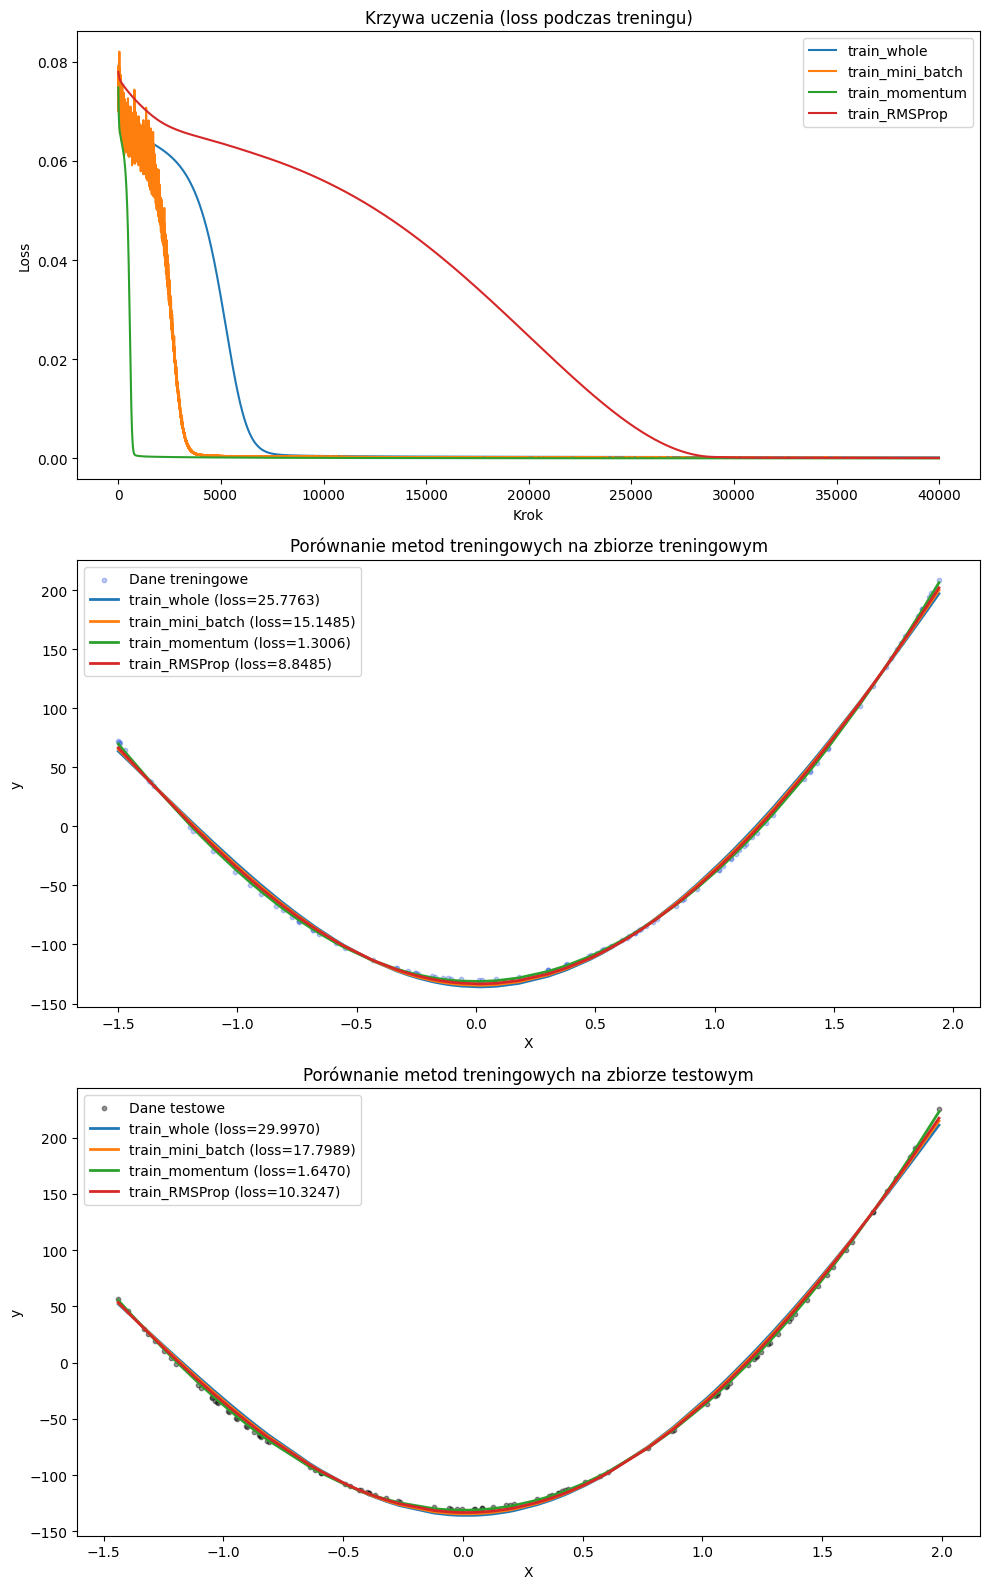

In [36]:
no_epochs = 40000
dane.train_whole(lr=0.1, epochs=no_epochs)
dane.train_mini_batch(lr=0.1, epochs=no_epochs, batch_size=64)
dane.train_momentum(lr=0.1, epochs=no_epochs, momentum=0.9)
dane.train_RMSProp(lr=0.0001, epochs=no_epochs, beta=0.9)
dane.evaluate()

### multimodal large

In [6]:
train_data = pd.read_csv('regression/multimodal-large-training.csv').to_numpy()
test_data = pd.read_csv('regression/multimodal-large-test.csv').to_numpy()
X_train = train_data[:, :-1]
y_train = train_data[:, -1:]
X_test = test_data[:, :-1]
y_test = test_data[:, -1:]

In [7]:
nn = NeuralNetwork(auto_layer_generator=[1,64,64,32 ,32, 1], activation_function="leaky_relu",weight_init="he")
dane = DANE(nn, mse_loss, mse_loss_gradient, X_train, y_train, X_test, y_test, standardize=False, normalize=True)

Trenowanie całym zbiorem
Epoka 100/1000, Loss: 0.08946019879829799
Epoka 200/1000, Loss: 0.07288732423669124
Epoka 300/1000, Loss: 0.06738397127103915
Epoka 400/1000, Loss: 0.0632530160152983
Epoka 500/1000, Loss: 0.060842965349295765
Epoka 600/1000, Loss: 0.057148867139076694
Epoka 700/1000, Loss: 0.05305744590743562
Epoka 800/1000, Loss: 0.047224658560503924
Epoka 900/1000, Loss: 0.0412239607085741
Epoka 999/1000, Loss: 0.03984600862152893
Epoka 1000/1000, Loss: 0.03643274046955182
Trenowanie mini-batchami
Epoka 0/1000, Loss: 0.11390329106836529
Epoka 100/1000, Loss: 0.004097788243239713
Epoka 200/1000, Loss: 0.0016472820210125343
Epoka 300/1000, Loss: 0.0007906796000841527
Epoka 400/1000, Loss: 0.0007508732603625546
Epoka 500/1000, Loss: 0.00027490806523070303
Epoka 600/1000, Loss: 0.00027534372267086005
Epoka 700/1000, Loss: 0.00033507683963510186
Epoka 800/1000, Loss: 0.0003104960325419665
Epoka 900/1000, Loss: 0.0002354380973643227
Epoka 999/1000, Loss: 0.00024116723118928275
Tre

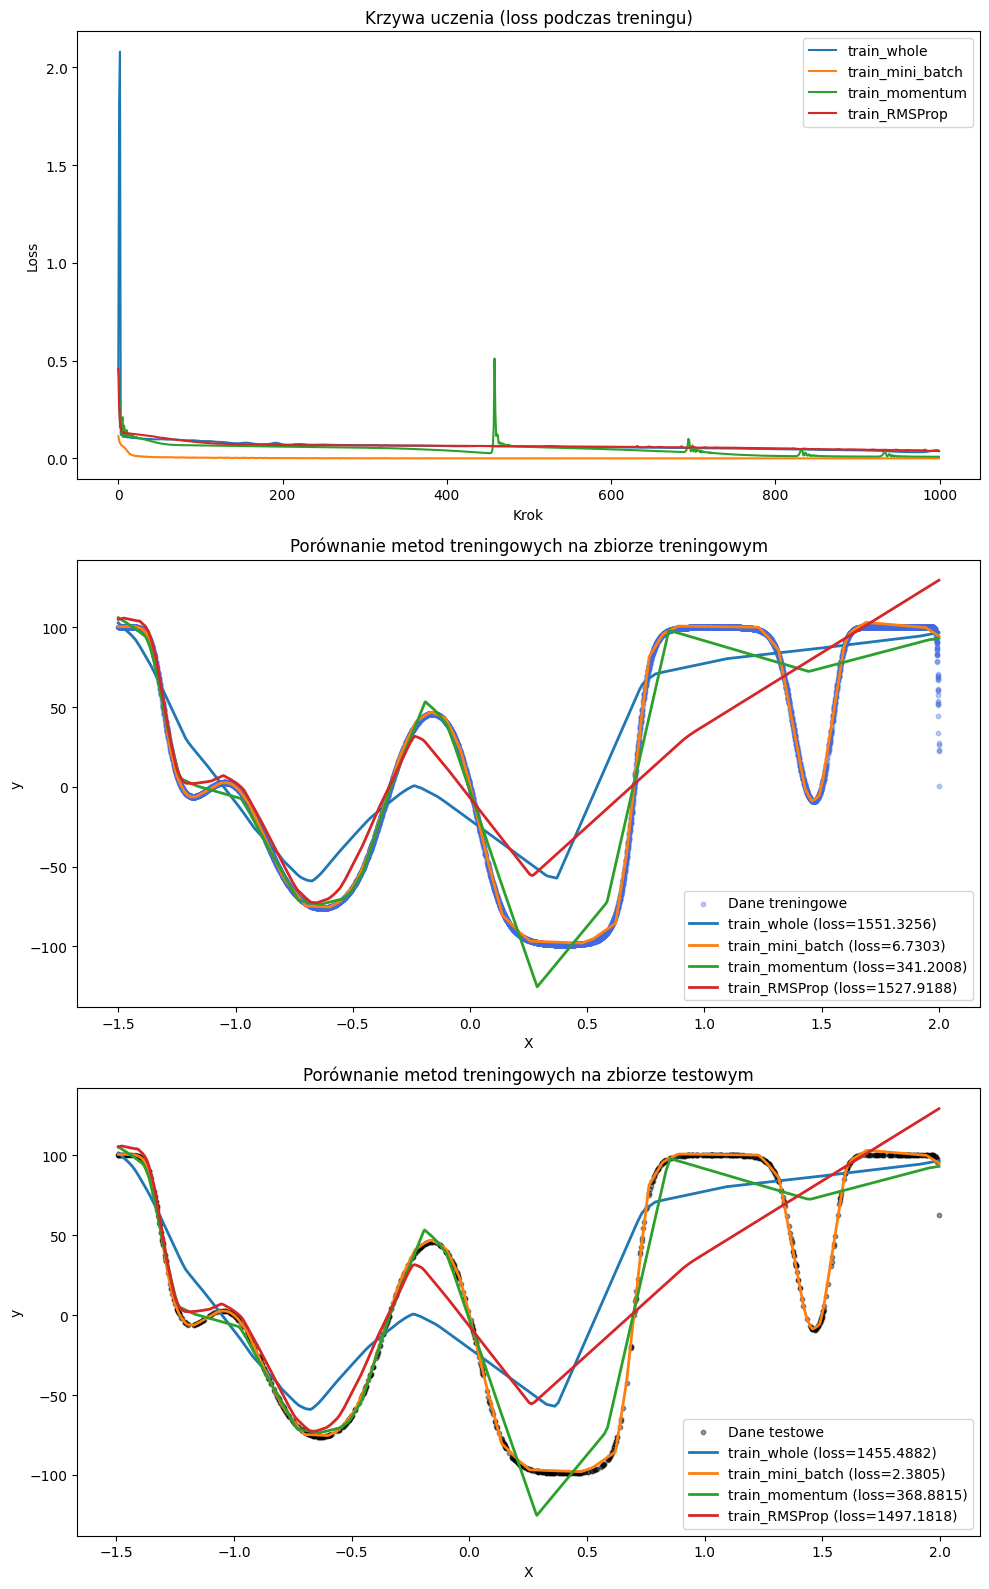

In [8]:
no_epochs = 1000
dane.train_whole(lr=0.1, epochs=no_epochs, verbose=True)
dane.train_mini_batch(lr=0.05, epochs=no_epochs, batch_size=64, verbose=True)
dane.train_momentum(lr=0.05, epochs=no_epochs, momentum=0.9, verbose=True)
dane.train_RMSProp(lr=0.0005, epochs=no_epochs, beta=0.9)
dane.evaluate()

### Steps small

In [ ]:
train_data = pd.read_csv('regression/steps-small-training.csv', index_col=0).to_numpy()
test_data = pd.read_csv('regression/steps-small-test.csv', index_col=0).to_numpy()
X_train = train_data[:, :-1]
y_train = train_data[:, -1:]
X_test = test_data[:, :-1]
y_test = test_data[:, -1:]


In [ ]:
nn = NeuralNetwork(auto_layer_generator=[1,128,64,32,32,1], activation_function="relu", weight_init="he")
dane = DANE(nn, mse_loss, mse_loss_gradient, 
            X_train, y_train, X_test, y_test, evaluation_metric=mse_loss, 
            standardize=False, normalize=True, stop_on_loss_threshold=1e-8)

Trenowanie całym zbiorem
Epoka 0/20000, Loss: 1.8985811478582886
Epoka 2000/20000, Loss: 0.0059225722306603746
Epoka 4000/20000, Loss: 0.005919739435315383
Epoka 6000/20000, Loss: 0.005919164992186167
Epoka 8000/20000, Loss: 0.005918881985052134
Epoka 10000/20000, Loss: 0.0059187203907451105
Epoka 12000/20000, Loss: 0.005918610251917263
Epoka 14000/20000, Loss: 0.005918527990784398
Epoka 16000/20000, Loss: 0.005918465133686502
Epoka 18000/20000, Loss: 0.005918419623383336
Epoka 19999/20000, Loss: 0.005918382439576077
Trenowanie mini-batchami
Epoka 0/20000, Loss: 0.33573425719571887
Epoka 2000/20000, Loss: 0.00616338597507271
Epoka 4000/20000, Loss: 0.006067636912884755
Epoka 6000/20000, Loss: 0.005821836030536748
Epoka 8000/20000, Loss: 0.00569641121402973
Epoka 10000/20000, Loss: 0.005643187618052745
Epoka 12000/20000, Loss: 0.005547395701403096
Epoka 14000/20000, Loss: 0.005450290422293156
Epoka 16000/20000, Loss: 0.005343294722372455
Epoka 18000/20000, Loss: 0.005126596010002795
Epo

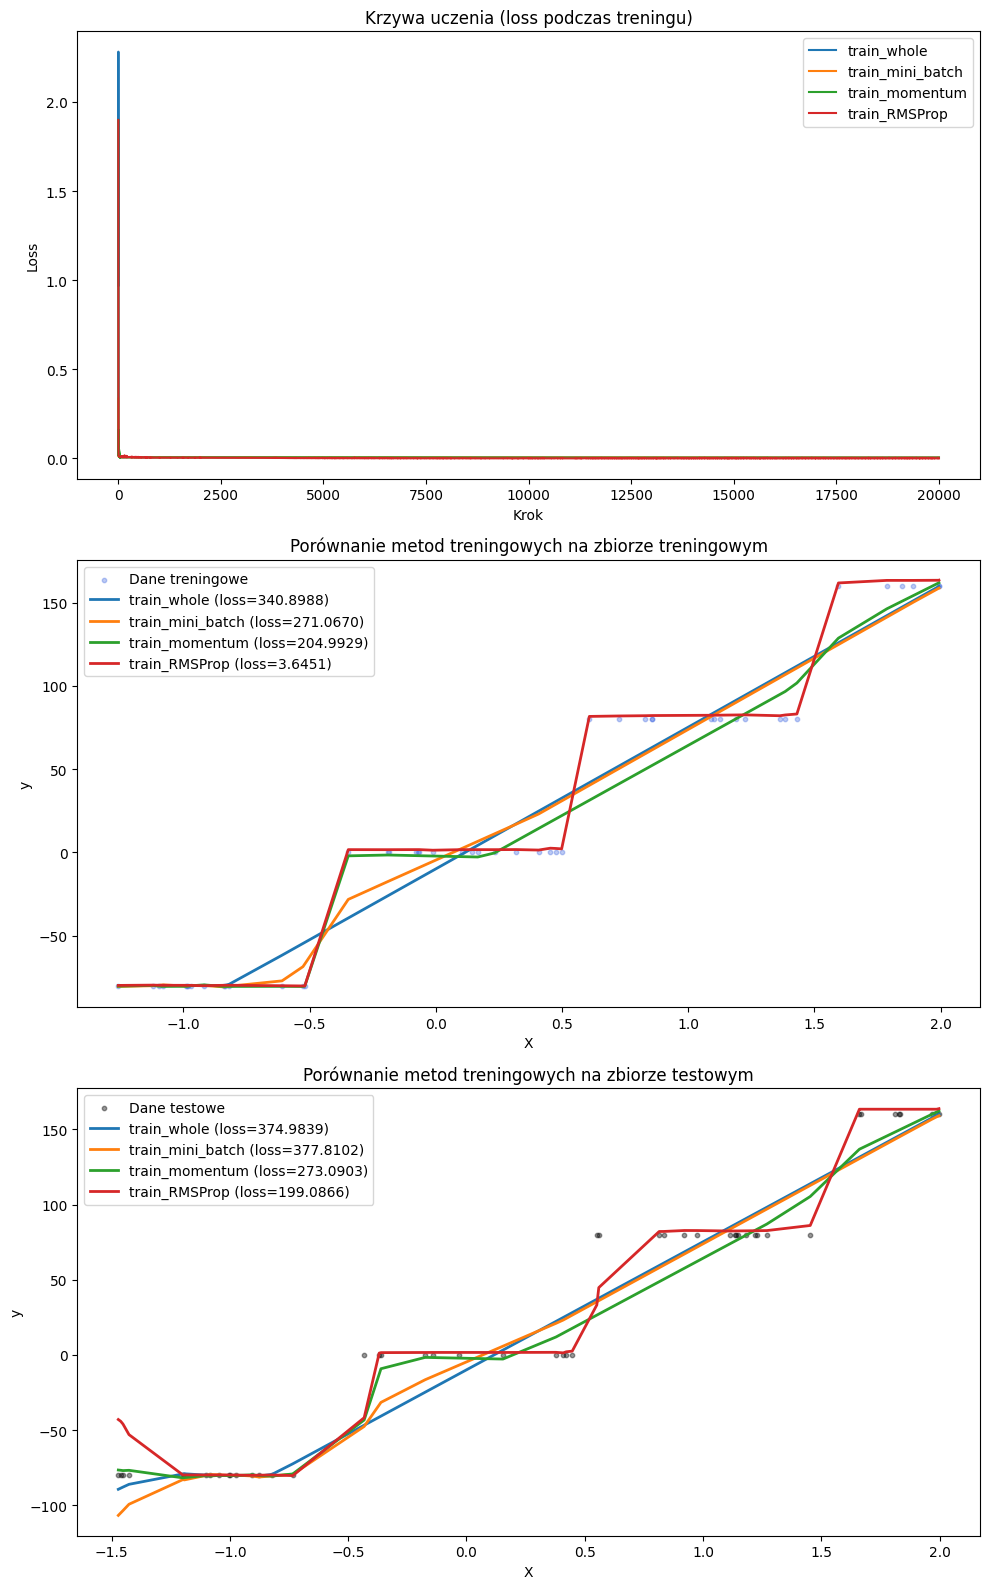

In [8]:
no_epochs = 20000
batch_size = 1
dane.train_whole(lr=0.03, epochs=no_epochs, verbose=True)
dane.train_mini_batch(lr=0.0005, epochs=no_epochs, batch_size=batch_size, verbose=True)
dane.train_momentum(lr=0.01, epochs=no_epochs, momentum=0.9, verbose=True)
dane.train_RMSProp(lr=0.0005, epochs=no_epochs, beta=0.95)
dane.evaluate()

## LAB 3

### Square large

In [18]:
train_data = pd.read_csv('regression/square-large-training.csv', index_col=0).to_numpy()
test_data = pd.read_csv('regression/square-large-test.csv', index_col=0).to_numpy()
X_train = train_data[:, :-1]
y_train = train_data[:, -1:]
X_test = test_data[:, :-1]
y_test = test_data[:, -1:]

In [19]:
nn = NeuralNetwork(auto_layer_generator=[1, 3, 1], activation_function="sigmoid", weight_init="xavier")
dane = DANE(nn, mse_loss, mse_loss_gradient, X_train, y_train, X_test, y_test )

Trenowanie całym zbiorem
Epoka 0/100000, Loss: 0.07035528707832844
Epoka 10000/100000, Loss: 0.0031616171270791743
Epoka 20000/100000, Loss: 0.0001830910444388392
Epoka 30000/100000, Loss: 0.00014319494329625865
Epoka 40000/100000, Loss: 0.00011338340003038539
Epoka 50000/100000, Loss: 9.080207994899925e-05
Epoka 60000/100000, Loss: 7.351446034231799e-05
Epoka 70000/100000, Loss: 6.0126370622944085e-05
Epoka 80000/100000, Loss: 4.9637261793552615e-05
Epoka 90000/100000, Loss: 4.132752584600662e-05
Epoka 99999/100000, Loss: 3.467642083538654e-05
Trenowanie z momentum
Epoka 10000/100000, Loss: 9.421978819187062e-05
Epoka 20000/100000, Loss: 3.590208988192172e-05
Epoka 30000/100000, Loss: 1.6374129357218645e-05
Epoka 40000/100000, Loss: 8.519245374222486e-06
Epoka 50000/100000, Loss: 5.002588534518755e-06
Epoka 60000/100000, Loss: 3.322447068129845e-06
Epoka 70000/100000, Loss: 2.482278130606053e-06
Epoka 80000/100000, Loss: 2.0450229915776764e-06
Epoka 90000/100000, Loss: 1.8071263440778

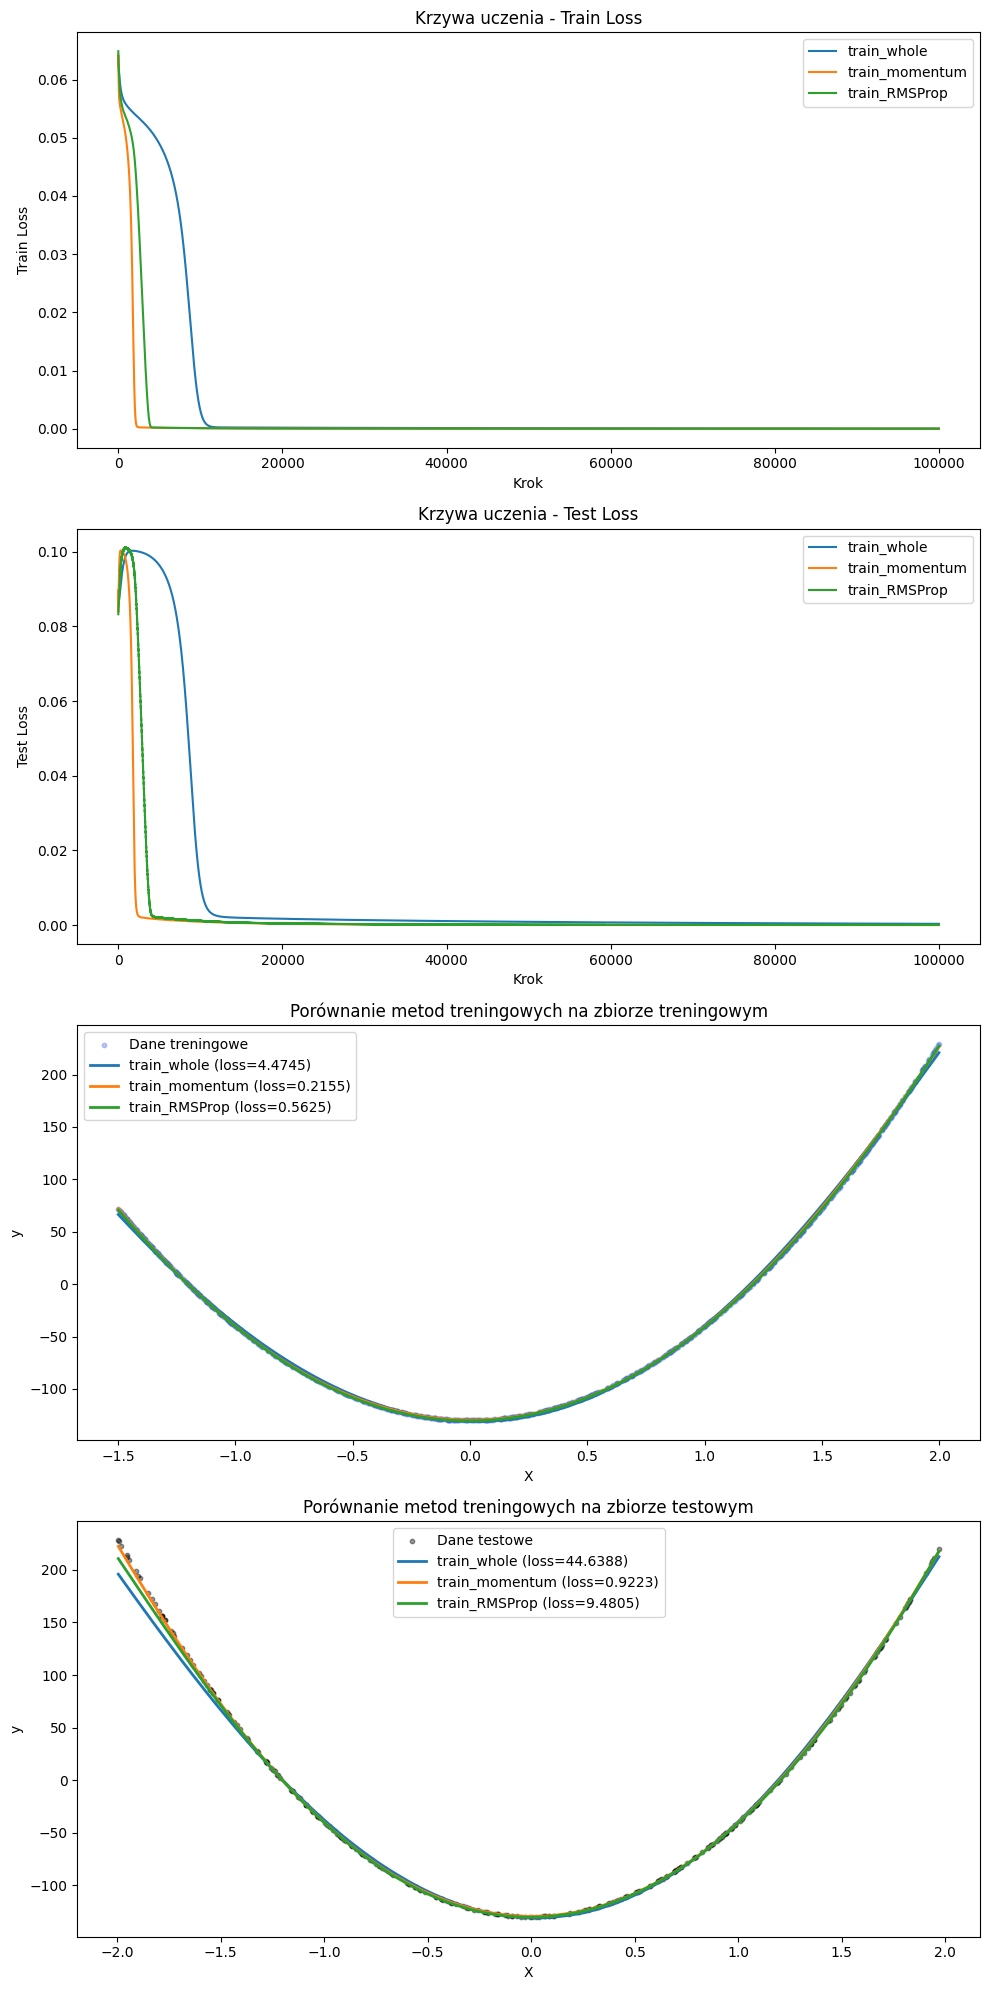

In [21]:
no_epochs = 100000
dane.train_whole(lr=0.1, epochs=no_epochs)
# dane.train_mini_batch(lr=0.1, epochs=no_epochs, batch_size=64)
dane.train_momentum(lr=0.05, epochs=no_epochs, momentum=0.9)
dane.train_RMSProp(lr=0.001, epochs=no_epochs, beta=0.9)
dane.evaluate()

### Steps Large

In [3]:
train_data = pd.read_csv('regression/steps-large-training.csv', index_col=0).to_numpy()
test_data = pd.read_csv('regression/steps-large-test.csv', index_col=0).to_numpy()
X_train = train_data[:, :-1]
y_train = train_data[:, -1:]
X_test = test_data[:, :-1]
y_test = test_data[:, -1:]

In [8]:
nn = NeuralNetwork(auto_layer_generator=[1,30,30,1], activation_function="relu", weight_init="he")
dane = DANE(nn, mse_loss, mse_loss_gradient, 
            X_train, y_train, X_test, y_test)

Trenowanie z RMSProp
Epoka 2000/20000, Loss: 0.005880728436932635
Epoka 4000/20000, Loss: 0.004816846833346557
Epoka 6000/20000, Loss: 0.0036268498861699683
Epoka 8000/20000, Loss: 0.0027896658694177732
Epoka 10000/20000, Loss: 0.0020681614050124283
Epoka 12000/20000, Loss: 0.0013831474463945803
Epoka 14000/20000, Loss: 0.0011758994933214369
Epoka 16000/20000, Loss: 0.001081626299204089
Epoka 18000/20000, Loss: 0.0007235982554596336
Epoka 19999/20000, Loss: 0.0006912340761894467
Epoka 20000/20000, Loss: 0.000747741726069835
Wyniki na zbiorach treningowym i testowym
  train_momentum: train loss = 303.536274, test loss = 299.237431, czas: 91.31s
  train_RMSProp: train loss = 46.392392, test loss = 40.635596, czas: 126.22s


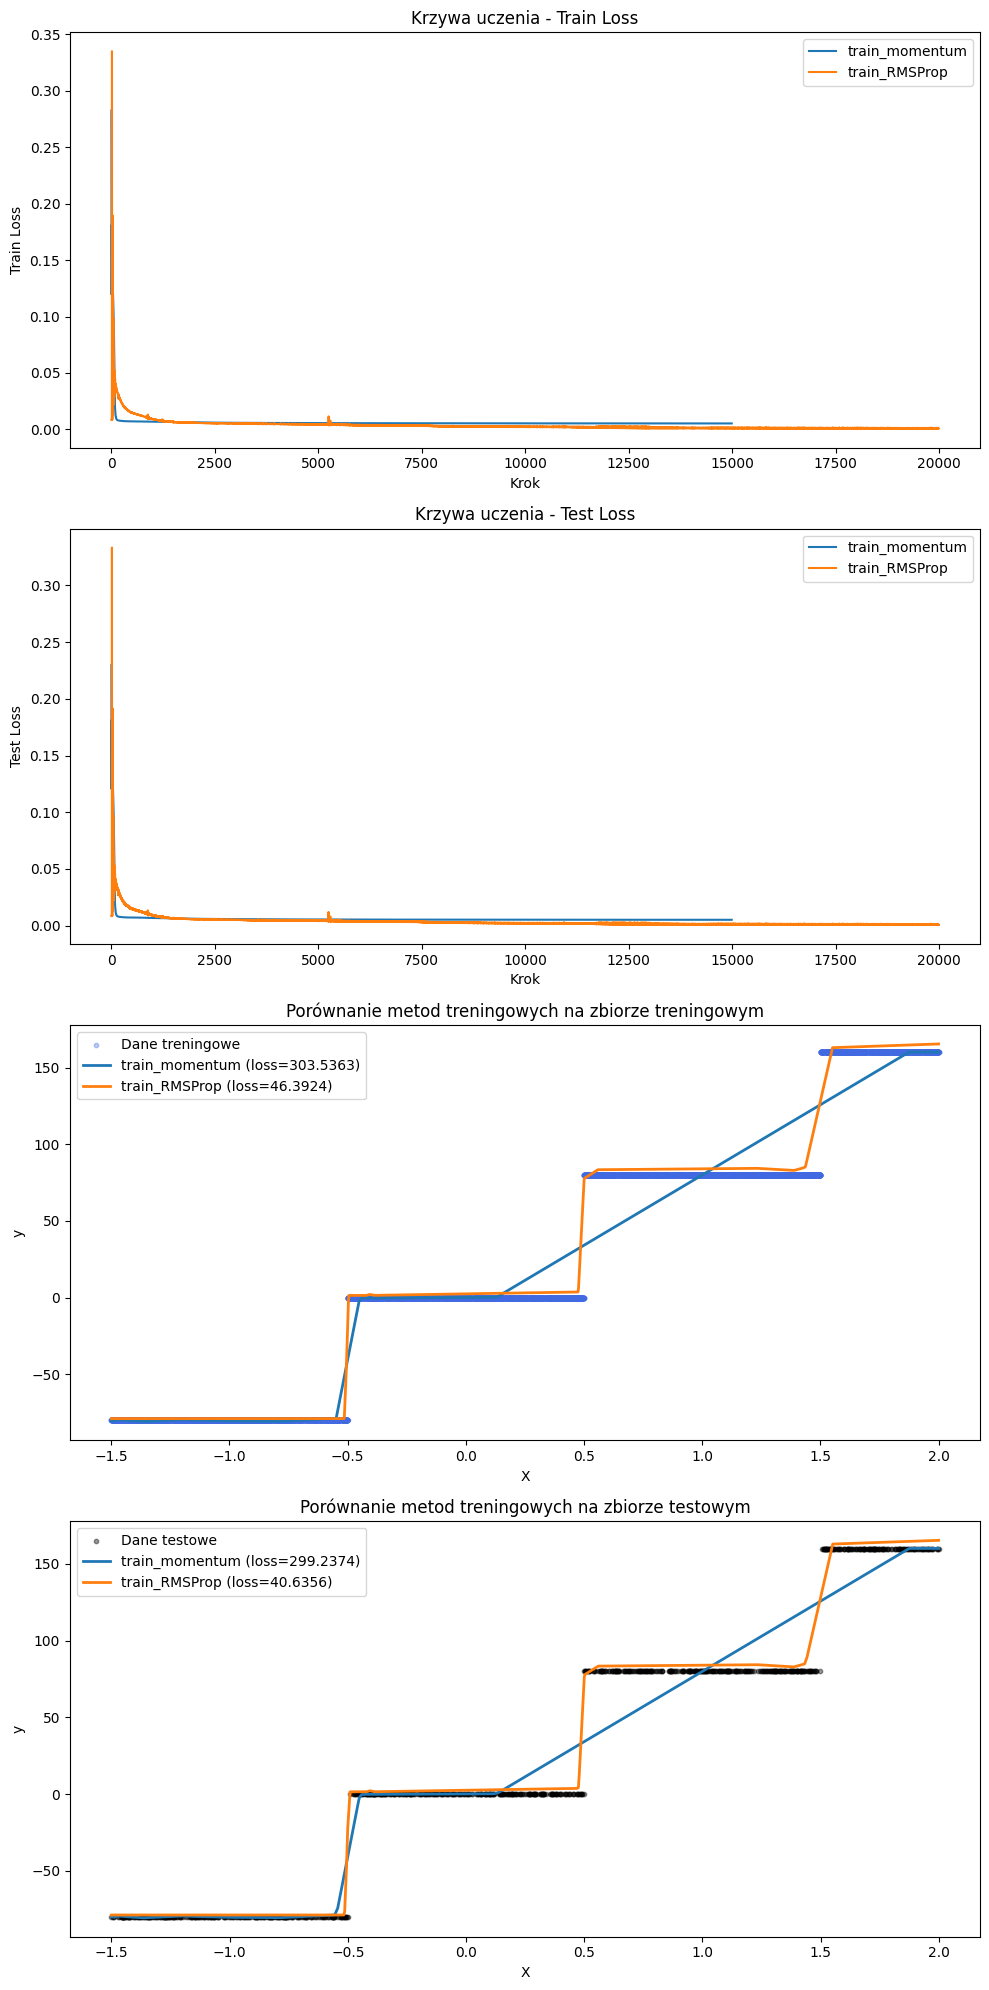

In [11]:
no_epochs = 20000
batch_size = 1
# dane.train_whole(lr=0.03, epochs=no_epochs, verbose=True)
# dane.train_mini_batch(lr=0.0005, epochs=no_epochs, batch_size=batch_size, verbose=True)
# dane.train_momentum(lr=0.025, epochs=no_epochs, momentum=0.9, verbose=True)
dane.train_RMSProp(lr=0.004, epochs=no_epochs, beta=0.9)
dane.evaluate()

### Multimodal Large

In [14]:
train_data = pd.read_csv('regression/multimodal-large-training.csv').to_numpy()
test_data = pd.read_csv('regression/multimodal-large-test.csv').to_numpy()
X_train = train_data[:, :-1]
y_train = train_data[:, -1:]
X_test = test_data[:, :-1]
y_test = test_data[:, -1:]

In [15]:
nn = NeuralNetwork(auto_layer_generator=[1,32,32, 1], activation_function="tanh",weight_init="xavier")
dane = DANE(nn, mse_loss, mse_loss_gradient, X_train, y_train, X_test, y_test, standardize=False, normalize=True)

In [ ]:
no_epochs = 4000
# dane.train_whole(lr=0.04, epochs=no_epochs, verbose=True)
dane.train_mini_batch(lr=0.05, epochs=no_epochs, batch_size=64, verbose=True)
# dane.train_momentum(lr=0.05, epochs=no_epochs, momentum=0.9, verbose=True)
# dane.train_RMSProp(lr=0.002, epochs=no_epochs, beta=0.9)
dane.evaluate()

Trenowanie mini-batchami
Epoka 0/4000, Loss: 0.11414913170894428
Epoka 400/4000, Loss: 0.015601752581402041
Epoka 800/4000, Loss: 0.008237084681861547


In [ ]:
op(lr=0.002, epochs=no_epochs, beta=0.9)
dane.evaluate()